# 09 — USBVPN2022 Integration and Audit

This notebook acts as a data adapter and audit tool to integrate the USBVPN2022 dataset
(provided in JSON format) into our existing AI-based VPN Firewall pipeline.

The pipeline currently processes ISCX2016 and VNAT datasets from PCAP files. To align the
USBVPN data with our direction-invariant schema:
1.  **Direction-Invariance:** Map upstream/downstream fields (`mean_ps_fwd`, `mean_ps_bwd`)
    to direction-agnostic columns (`sz_mean_max`, `sz_mean_min`, `iat_mean_max`, `iat_mean_min`).
2.  **Schema Alignment:** The output is a Parquet file (`data/processed/usbvpn/flows.parquet`)
    containing required pipeline columns (`flow_id`, `capture_id`, `label`, `dataset`, etc.).
    Since the raw histogram windows are missing in the JSON, we fill them with `0.0`.
3.  **Data Splitting:** We map each JSON source file to a unique `capture_id` and apply a
    Group-Based Split (70% train, 15% val, 15% test) to prevent leakage.
4.  **Audit Section:** Pre-flight checks on feature shifts and a "Dataset Detector" test.

In [1]:
%matplotlib inline

import json
import warnings
from pathlib import Path
from datetime import datetime
import collections

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import roc_auc_score, classification_report

from src.utils.paths import load_paths
from src.utils.logging import setup_logger
from src.features.extract import load_feature_config, extract_features_from_flows

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

paths = load_paths()
paths.ensure_dirs()
logger = setup_logger(level="INFO")

# Define Paths
USBVPN_RAW_DIR = paths.data_raw_dir / "usbvpn" # Adjust this path as necessary
PROCESSED_USBVPN_DIR = paths.data_processed_dir / "usbvpn"
PROCESSED_USBVPN_DIR.mkdir(parents=True, exist_ok=True)
FLOWS_PARQUET_PATH = PROCESSED_USBVPN_DIR / "flows.parquet"

logger.info(f"Raw USBVPN dir expected at: {USBVPN_RAW_DIR}")
logger.info(f"Processed USBVPN Parquet will be saved to: {FLOWS_PARQUET_PATH}")

2026-03-25 15:18:47 | INFO | ai-vpn-firewall | Raw USBVPN dir expected at: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\data\raw\usbvpn
2026-03-25 15:18:47 | INFO | ai-vpn-firewall | Processed USBVPN Parquet will be saved to: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\data\processed\usbvpn\flows.parquet


## 1. Data Adapter Function

The JSON dataset uses direction-based features and is scattered across multiple files in `vpn/` and `nonvpn/` subdirectories.
We iterate through all JSON files, parse the raw packet data (`x_packets`), and convert them to our direction-invariant
min/max schema. Since `h_size_all_*` and `h_iat_all_*` histograms aren't easily constructible without the full flow context, we zero-fill them
to keep the `FeaturePipeline` happy.

In [2]:
def _calculate_flow_stats_from_packets(packets: list) -> dict:
    """Calculates necessary statistics from a list of packet dictionaries."""
    if not packets:
        return {}

    sizes_fwd = []
    sizes_bwd = []
    times_all = []

    # Format expected: "2022-09-26 12:52:59.890431"
    time_fmt = "%Y-%m-%d %H:%M:%S.%f"

    for p in packets:
        try:
            b = int(p.get("bytes", 0))
            if b > 0:
                sizes_fwd.append(b)
            elif b < 0:
                sizes_bwd.append(abs(b))

            ts_str = p.get("timestamp_start")
            if ts_str:
                 try:
                     ts = datetime.strptime(ts_str, time_fmt).timestamp()
                     times_all.append(ts)
                 except ValueError:
                     pass # ignore unparseable timestamps
        except ValueError:
             continue

    sizes_all = sizes_fwd + sizes_bwd
    times_all.sort()

    iats_all = np.diff(times_all) if len(times_all) > 1 else np.array([])

    def calc_stats(arr):
        if len(arr) == 0:
            return 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
        return (
            float(np.mean(arr)),
            float(np.std(arr, ddof=0)) if len(arr) > 1 else 0.0,
            float(np.min(arr)),
            float(np.max(arr)),
            float(np.median(arr)),
            float(np.percentile(arr, 25)),
            float(np.percentile(arr, 75))
        )

    sz_all_mean, sz_all_std, _, _, sz_all_median, sz_all_p25, sz_all_p75 = calc_stats(sizes_all)
    sz_fwd_mean, sz_fwd_std, _, _, _, _, _ = calc_stats(sizes_fwd)
    sz_bwd_mean, sz_bwd_std, _, _, _, _, _ = calc_stats(sizes_bwd)

    iat_all_mean, iat_all_std, _, _, iat_all_median, iat_all_p25, iat_all_p75 = calc_stats(iats_all)

    # Coefficient of Variation: unitless burstiness metric
    sz_cv = sz_all_std / sz_all_mean if sz_all_mean > 0 else 0.0

    # Note: We can't easily calculate directional IATs from this data format because we only have
    # overall timestamps, not directional ones. We will approximate directional IATs with overall IATs
    # for the purpose of the min/max mapping. This is a compromise due to data limitations.
    iat_fwd_mean = iat_all_mean
    iat_bwd_mean = iat_all_mean
    iat_fwd_std = iat_all_std
    iat_bwd_std = iat_all_std

    return {
        "sz_all_mean": sz_all_mean,
        "sz_all_std": sz_all_std,
        "sz_cv": sz_cv,
        "sz_all_median": sz_all_median,
        "sz_all_p25": sz_all_p25,
        "sz_all_p75": sz_all_p75,

        "sz_mean_max": max(sz_fwd_mean, sz_bwd_mean),
        "sz_mean_min": min(sz_fwd_mean, sz_bwd_mean),
        "sz_std_max": max(sz_fwd_std, sz_bwd_std),
        "sz_std_min": min(sz_fwd_std, sz_bwd_std),

        "iat_all_mean": iat_all_mean,
        "iat_all_std": iat_all_std,
        "iat_all_median": iat_all_median,
        "iat_all_p25": iat_all_p25,
        "iat_all_p75": iat_all_p75,

        "iat_mean_max": max(iat_fwd_mean, iat_bwd_mean),
        "iat_mean_min": min(iat_fwd_mean, iat_bwd_mean),
        "iat_std_max": max(iat_fwd_std, iat_bwd_std),
        "iat_std_min": min(iat_fwd_std, iat_bwd_std),

        "tot_pkt": len(sizes_all)
    }

def adapt_usbvpn_to_pipeline(raw_dir: Path) -> pd.DataFrame:
    """
    Loads USBVPN JSON files and adapts them to the direction-invariant schema.

    Important:
    - capture_id is synthetic chunk group for split control
    - source_capture_id preserves original source-file identity for stricter evaluation
    - source_capture_id is metadata only and must never be used as a model feature
    """
    logger.info(f"Loading JSONs from: {raw_dir}")

    if not raw_dir.exists():
        raise FileNotFoundError(f"USBVPN raw dir not found: {raw_dir}")

    json_files = list(raw_dir.rglob("*.json"))
    logger.info(f"Found {len(json_files)} JSON files in {raw_dir}")

    # REDUCED subcapture size to increase VPN representation in test split
    USBVPN_SUBCAPTURE_SIZE = 100

    all_records = []
    for jf in json_files:
        try:
            with open(jf, "r", encoding="utf-8") as f:
                data = json.load(f)

            if not isinstance(data, list):
                logger.warning(f"Unexpected JSON structure in {jf}. Expected list of flows.")
                continue

            for i, flow_data in enumerate(data):
                packets = flow_data.get("x_packets", [])
                stats = _calculate_flow_stats_from_packets(packets)
                if not stats:
                    continue

                subcapture_id = f"{jf.stem}__chunk_{i // USBVPN_SUBCAPTURE_SIZE:04d}"

                record = {
                    "flow_id": f"{jf.stem}_{i}",
                    "capture_id": subcapture_id,
                    "source_capture_id": jf.stem,
                    "source_file": jf.name,
                    "dataset": "usbvpn",
                }

                jf_lower = str(jf).lower()
                if "nonvpn" in jf_lower or "non-vpn" in jf_lower:
                    record["label"] = 0
                elif "vpn" in jf_lower:
                    record["label"] = 1
                else:
                    record["label"] = 0

                record.update(stats)
                all_records.append(record)

        except Exception as e:
            logger.error(f"Error parsing JSON {jf}: {e}")

    if not all_records:
        raise ValueError(f"No valid records extracted from JSON files in {raw_dir}")

    df_out = pd.DataFrame(all_records)
    logger.info(f"Extracted {len(df_out)} flows from raw data.")

    df_out["q_packet_count"] = df_out.get("tot_pkt", pd.Series(100, index=df_out.index))
    df_out["q_min_packets_ok"] = (df_out["q_packet_count"] >= 10).astype(float)
    df_out["q_window_complete"] = 1.0

    for i in range(7):
        df_out[f"h_size_all_{i:02d}"] = 0.0
    for i in range(12):
        df_out[f"h_iat_all_{i:02d}"] = 0.0

    for metric in ["median", "p25", "p75"]:
        if f"sz_all_{metric}" not in df_out.columns:
            df_out[f"sz_all_{metric}"] = df_out["sz_all_mean"]
        if f"iat_all_{metric}" not in df_out.columns:
            df_out[f"iat_all_{metric}"] = df_out["iat_all_mean"]

    return df_out

df_usbvpn = adapt_usbvpn_to_pipeline(USBVPN_RAW_DIR)
logger.info(f"Adapted USBVPN shape: {df_usbvpn.shape}")
print(df_usbvpn.head())

2026-03-25 15:18:47 | INFO | ai-vpn-firewall | Loading JSONs from: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\data\raw\usbvpn
2026-03-25 15:18:47 | INFO | ai-vpn-firewall | Found 35 JSON files in C:\Users\scoti\PycharmProjects\ai-vpn-firewall\data\raw\usbvpn
2026-03-25 15:42:21 | INFO | ai-vpn-firewall | Extracted 58977 flows from raw data.
2026-03-25 15:42:21 | INFO | ai-vpn-firewall | Adapted USBVPN shape: (58977, 48)
  flow_id        capture_id source_capture_id source_file dataset  label  \
0  mail_0  mail__chunk_0000              mail   mail.json  usbvpn      0   
1  mail_1  mail__chunk_0000              mail   mail.json  usbvpn      0   
2  mail_2  mail__chunk_0000              mail   mail.json  usbvpn      0   
3  mail_3  mail__chunk_0000              mail   mail.json  usbvpn      0   
4  mail_4  mail__chunk_0000              mail   mail.json  usbvpn      0   

   sz_all_mean  sz_all_std     sz_cv  sz_all_median  ...  h_iat_all_02  \
0   439.774011   82.107514  0.186704     

## 2. Capture-Level (Group) Data Splitting

We use a Group-Based Split to ensure that all flows from a single `capture_id` (JSON file)
stay together in either Train, Val, or Test. This prevents "Capture Overlap" leakage.

*   Train: 70%
*   Val: 15%
*   Test: 15%

In [25]:
def group_based_split(df: pd.DataFrame, group_col: str = "capture_id", label_col: str = "label", random_state: int = 45) -> pd.DataFrame:
    """
    Final Balanced Split Strategy:
    1. Normalizes IDs to prevent naming mismatches (e.g. .pcap vs no extension)
    2. Forces SSH and WireGuard to TEST for zero-shot validation.
    3. Stratifies the rest by protocol and label.
    """
    df = df.copy()

    # Pre-processing: Ensure capture_id strings are clean for matching
    df[group_col] = df[group_col].astype(str).str.replace(".pcapng", "").str.replace(".pcap", "").str.strip()

    # 1. Create session-level metadata
    meta = df.groupby(group_col).agg({
        label_col: 'max',
        'source_capture_id': 'first'
    }).reset_index()

    # 2. FORCE ZERO-SHOT PROTOCOLS TO TEST
    # We use a case-insensitive check
    zero_shot_protocols = ['ssh', 'wireguard']
    is_zero_shot = meta['source_capture_id'].str.lower().str.contains('|'.join(zero_shot_protocols))

    meta_zero_shot = meta[is_zero_shot].copy()
    meta_regular = meta[~is_zero_shot].copy()

    # 3. Stratify the regular data
    # Combine label and source file to ensure we don't put all 'Mail' in Train
    meta_regular["strat_key"] = meta_regular[label_col].astype(str) + "_" + meta_regular["source_capture_id"].astype(str)

    # Handle protocols with only 1 chunk (prevents ValueError)
    counts = meta_regular["strat_key"].value_counts()
    valid_keys = counts[counts >= 2].index
    meta_regular["final_strat"] = meta_regular["strat_key"].where(meta_regular["strat_key"].isin(valid_keys), meta_regular[label_col].astype(str))

    # --- Step 1: Split into Train (70%) vs Temp (30%) ---
    train_idx, temp_idx = train_test_split(
        meta_regular.index,
        test_size=0.3,
        stratify=meta_regular["final_strat"],
        random_state=random_state
    )

    # --- Step 2: Split Temp into Val (15%) and Test (15%) ---
    # We aim for a balanced distribution here
    val_idx, test_idx_reg = train_test_split(
        temp_idx,
        test_size=0.5,
        stratify=meta_regular.loc[temp_idx, "label"],
        random_state=random_state
    )

    train_caps = meta_regular.loc[train_idx, group_col]
    val_caps = meta_regular.loc[val_idx, group_col]
    test_caps = pd.concat([meta_regular.loc[test_idx_reg, group_col], meta_zero_shot[group_col]])

    # 4. Apply to main dataframe
    df["split"] = "train" # Default
    df.loc[df[group_col].isin(val_caps), "split"] = "val"
    df.loc[df[group_col].isin(test_caps), "split"] = "test"
    df.loc[df[group_col].isin(train_caps), "split"] = "train"

    return df

df_usbvpn_split = group_based_split(df_usbvpn)

print("\n--- Leakage Verification ---")
train_caps_verify = set(df_usbvpn_split[df_usbvpn_split["split"] == "train"]["capture_id"])
val_caps_verify = set(df_usbvpn_split[df_usbvpn_split["split"] == "val"]["capture_id"])
test_caps_verify = set(df_usbvpn_split[df_usbvpn_split["split"] == "test"]["capture_id"])

print(f"Train/Test Overlap: {train_caps_verify & test_caps_verify}")
print(f"Train/Val Overlap: {train_caps_verify & val_caps_verify}")
print(f"Val/Test Overlap: {val_caps_verify & test_caps_verify}")

print("\n--- Split Distribution Summary ---")
summary = []
for s in ["train", "val", "test"]:
    sub = df_usbvpn_split[df_usbvpn_split["split"] == s]
    summary.append({
        "Split": s,
        "Unique synthetic groups": sub["capture_id"].nunique(),
        "Unique source files": sub["source_capture_id"].nunique() if "source_capture_id" in sub.columns else np.nan,
        "Total Flows": len(sub),
        "VPN %": f"{100 * sub['label'].mean():.1f}%" if len(sub) else "0.0%"
    })

print(pd.DataFrame(summary).to_string(index=False))

if df_usbvpn_split.groupby("split")["capture_id"].nunique().min() < 3:
    raise ValueError(
        "USBVPN split still has too few synthetic capture groups. "
        "Reduce USBVPN_SUBCAPTURE_SIZE."
    )

df_usbvpn_split.to_parquet(FLOWS_PARQUET_PATH, index=False)
logger.info(f"Saved prepared USBVPN flows to {FLOWS_PARQUET_PATH}")


--- Leakage Verification ---
Train/Test Overlap: set()
Train/Val Overlap: set()
Val/Test Overlap: set()

--- Split Distribution Summary ---
Split  Unique synthetic groups  Unique source files  Total Flows VPN %
train                      352                    3        41833 16.2%
  val                       75                    3         8142  8.2%
 test                       77                    3         9002 15.1%
2026-03-25 16:54:31 | INFO | ai-vpn-firewall | Saved prepared USBVPN flows to C:\Users\scoti\PycharmProjects\ai-vpn-firewall\data\processed\usbvpn\flows.parquet


## 3. Pre-flight Audit: Feature and Label Distribution

We want to visualize the label distribution and compare the adapted feature distributions
to see what kind of domain shift we are introducing.

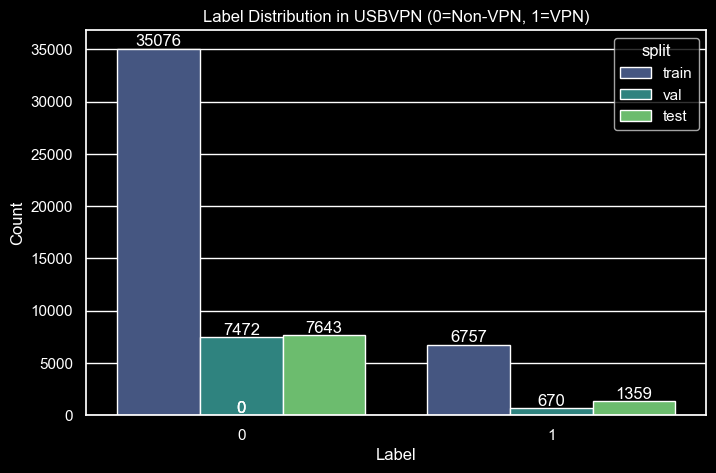

2026-03-25 17:12:27 | INFO | ai-vpn-firewall | Loaded and extracted features from ISCX flows: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\data\processed\iscx\flows.parquet
2026-03-25 17:12:57 | INFO | ai-vpn-firewall | Loaded and extracted features from VNAT flows: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\data\processed\vnat\flows.parquet
2026-03-25 17:12:57 | INFO | ai-vpn-firewall | Combined existing extracted features shape: (110398, 45)


C:\Users\scoti\PycharmProjects\ai-vpn-firewall\.venv\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


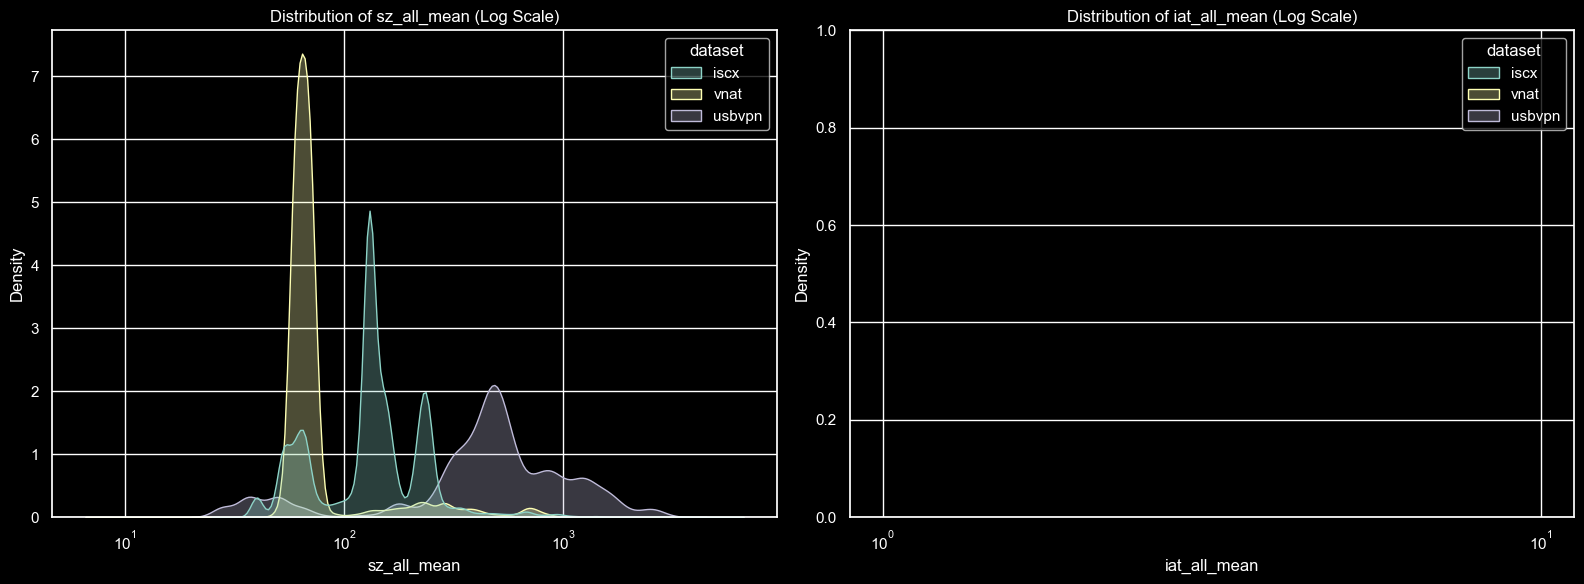

In [30]:
# 1. Label Distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_usbvpn_split, x="label", hue="split", palette="viridis")
plt.title("Label Distribution in USBVPN (0=Non-VPN, 1=VPN)")
plt.xlabel("Label")
plt.ylabel("Count")
for p in ax.patches:
    height = p.get_height()
    if pd.notna(height):
        ax.annotate(f"{int(height)}", (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

# Load existing prepared data (VNAT + ISCX) to compare
COMPARE_EXISTING = False
df_existing = None
try:
    from src.features.extract import load_feature_config, extract_features_from_flows
    iscx_flows_path = paths.data_processed_dir / "iscx" / "flows.parquet"
    vnat_flows_path = paths.data_processed_dir / "vnat" / "flows.parquet"

    dfs_to_concat = []

    # Get the feature config to extract features from the raw flows for a fair comparison
    features_yaml = paths.configs_dir / "features.yaml"
    cfg = load_feature_config(features_yaml)

    if iscx_flows_path.exists():
        raw_iscx = pd.read_parquet(iscx_flows_path)
        # Extract features to match USBVPN format
        feat_iscx = extract_features_from_flows(raw_iscx, cfg)
        feat_iscx['dataset'] = 'iscx'
        dfs_to_concat.append(feat_iscx)
        logger.info(f"Loaded and extracted features from ISCX flows: {iscx_flows_path}")
    else:
        logger.warning(f"ISCX flows not found at {iscx_flows_path}.")

    if vnat_flows_path.exists():
        raw_vnat = pd.read_parquet(vnat_flows_path)
        # Extract features to match USBVPN format
        feat_vnat = extract_features_from_flows(raw_vnat, cfg)
        feat_vnat['dataset'] = 'vnat'
        dfs_to_concat.append(feat_vnat)
        logger.info(f"Loaded and extracted features from VNAT flows: {vnat_flows_path}")
    else:
        logger.warning(f"VNAT flows not found at {vnat_flows_path}.")

    if dfs_to_concat:
        df_existing = pd.concat(dfs_to_concat, ignore_index=True)
        logger.info(f"Combined existing extracted features shape: {df_existing.shape}")

        # We need overlapping columns
        overlap_cols = ["dataset", "sz_all_mean", "iat_all_mean"]

        df_vis = pd.concat([
            df_existing[overlap_cols].dropna(),
            df_usbvpn_split[overlap_cols].dropna()
        ], ignore_index=True)

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", UserWarning) # Ignore seaborn 0 variance warnings for dummy data
            sns.kdeplot(data=df_vis, x="sz_all_mean", hue="dataset", ax=axes[0], log_scale=True, common_norm=False, fill=True, alpha=0.3)
            axes[0].set_title("Distribution of sz_all_mean (Log Scale)")

            sns.kdeplot(data=df_vis, x="iat_all_mean", hue="dataset", ax=axes[1], log_scale=True, common_norm=False, fill=True, alpha=0.3)
            axes[1].set_title("Distribution of iat_all_mean (Log Scale)")

        plt.tight_layout()
        plt.show()

        COMPARE_EXISTING = True
    else:
        logger.warning("No existing flows (ISCX or VNAT) found. Skipping comparison.")
        COMPARE_EXISTING = False

except Exception as e:
    logger.error(f"Error loading existing flows for comparison: {e}")
    COMPARE_EXISTING = False

## 4. Dataset Detector Audit (XGBoost)

We will train an XGBoost model to classify `usbvpn` vs `existing datasets`.
If the AUC is very high (> 0.95), it means USBVPN features are drastically different
(domain shift) and integrating them seamlessly might be challenging for the main pipeline.

2026-03-25 17:12:59 | INFO | ai-vpn-firewall | Training Dataset Detector (USBVPN vs Others)...

Dataset Detector Results (Target=USBVPN):
Test AUC: 0.9974

Classification Report:
              precision    recall  f1-score   support

   ISCX/VNAT       0.99      0.98      0.99     33120
      USBVPN       0.94      0.97      0.96      9002

    accuracy                           0.98     42122
   macro avg       0.97      0.98      0.97     42122
weighted avg       0.98      0.98      0.98     42122



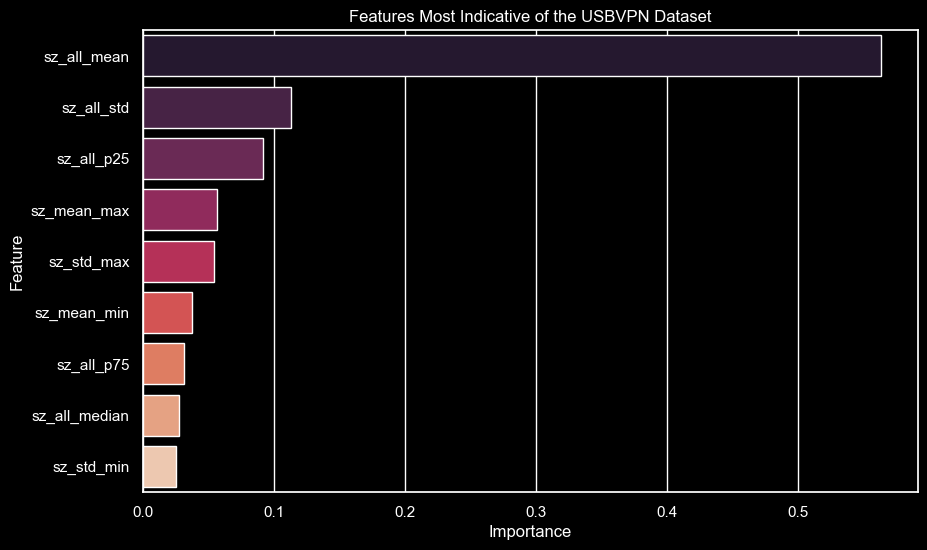

2026-03-25 17:13:00 | WARNING | ai-vpn-firewall | HIGH DOMAIN SHIFT DETECTED. The model can easily distinguish USBVPN from ISCX/VNAT.
2026-03-25 17:13:00 | WARNING | ai-vpn-firewall | Consider feature pruning or domain adaptation techniques in the main pipeline.


In [31]:
if COMPARE_EXISTING and df_existing is not None:
    # Prepare data for dataset detector
    feature_cols = [
        "sz_all_mean", "sz_all_std", "sz_all_p25",
        "sz_all_median", "sz_all_p75", "sz_mean_max",
        "sz_mean_min", "sz_std_max", "sz_std_min"
    ]

    # Target: 1 if usbvpn, 0 if vnat/iscx
    df_existing["is_usbvpn"] = 0
    df_usbvpn_split["is_usbvpn"] = 1

    # We use only 'train' splits for fitting the detector to avoid test set leakage
    # If 'split' is missing in existing data (e.g. not prepared yet), we just use all of it
    if "split" in df_existing.columns:
        train_existing = df_existing[df_existing["split"] == "train"]
        test_existing = df_existing[df_existing["split"] == "test"]
    else:
        # Fallback if split info isn't there yet
        train_existing, test_existing = train_test_split(df_existing, test_size=0.3, random_state=42)

    train_usbvpn = df_usbvpn_split[df_usbvpn_split["split"] == "train"]
    test_usbvpn = df_usbvpn_split[df_usbvpn_split["split"] == "test"]

    df_det_train = pd.concat([train_existing, train_usbvpn], ignore_index=True)
    df_det_test = pd.concat([test_existing, test_usbvpn], ignore_index=True)

    # Ensure all required features exist in existing data
    missing_feats = [c for c in feature_cols if c not in df_det_train.columns]
    if missing_feats:
         logger.warning(f"Missing features in existing data: {missing_feats}. Dropping from detector.")
         feature_cols = [c for c in feature_cols if c in df_det_train.columns]

    df_det_train = df_det_train.dropna(subset=feature_cols)
    df_det_test = df_det_test.dropna(subset=feature_cols)

    X_tr = df_det_train[feature_cols].to_numpy()
    y_tr = df_det_train["is_usbvpn"].to_numpy()

    X_te = df_det_test[feature_cols].to_numpy()
    y_te = df_det_test["is_usbvpn"].to_numpy()

    logger.info("Training Dataset Detector (USBVPN vs Others)...")
    clf_detector = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        eval_metric="auc",
        random_state=42,
        n_jobs=4
    )

    clf_detector.fit(X_tr, y_tr)

    p_te = clf_detector.predict_proba(X_te)[:, 1]
    y_pred = (p_te > 0.5).astype(int)

    auc = roc_auc_score(y_te, p_te)

    print("\nDataset Detector Results (Target=USBVPN):")
    print(f"Test AUC: {auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_te, y_pred, target_names=["ISCX/VNAT", "USBVPN"]))

    # Feature Importance
    imp = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": clf_detector.feature_importances_
    }).sort_values("Importance", ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=imp, x="Importance", y="Feature", hue="Feature", palette="rocket", legend=False)
    plt.title("Features Most Indicative of the USBVPN Dataset")
    plt.show()

    if auc > 0.95:
        logger.warning("HIGH DOMAIN SHIFT DETECTED. The model can easily distinguish USBVPN from ISCX/VNAT.")
        logger.warning("Consider feature pruning or domain adaptation techniques in the main pipeline.")
    else:
        logger.info("Moderate domain shift. The datasets have overlapping feature spaces.")
else:
    print("Cannot run Dataset Detector: Existing flows.parquet not found.")

## Schema Alignment Test

This section verifies that the newly processed USBVPN data has the exact same feature schema as the
existing ISCX and VNAT datasets before moving on to joint training.

In [32]:
logger.info("Running Schema Alignment Test...")

# Load USBVPN data we just created
usbvpn_test_df = pd.read_parquet(FLOWS_PARQUET_PATH)
usbvpn_cols = set(usbvpn_test_df.columns)

if df_existing is not None:
    existing_cols = set(df_existing.columns)

    # Find mismatches
    in_usbvpn_not_existing = usbvpn_cols - existing_cols
    in_existing_not_usbvpn = existing_cols - usbvpn_cols

    # We only care about feature columns, not metadata like 'app' or 'connection_str' which USBVPN doesn't have
    feature_mismatch_usbvpn = [c for c in in_usbvpn_not_existing if c.startswith('sz_') or c.startswith('iat_') or c.startswith('h_') or c.startswith('q_')]
    feature_mismatch_existing = [c for c in in_existing_not_usbvpn if c.startswith('sz_') or c.startswith('iat_') or c.startswith('h_') or c.startswith('q_')]

    if feature_mismatch_usbvpn or feature_mismatch_existing:
        logger.error("SCHEMA MISMATCH DETECTED!")
        if feature_mismatch_usbvpn:
            logger.error(f"Features in USBVPN but NOT in existing data: {feature_mismatch_usbvpn}")
        if feature_mismatch_existing:
            logger.error(f"Features in existing data but NOT in USBVPN: {feature_mismatch_existing}")
        raise ValueError("USBVPN schema does not align with existing VNAT/ISCX features. Parquet.")
    else:
        logger.info("SUCCESS: USBVPN feature schema perfectly aligns with existing data.")
        print("\nAligned Feature Schema Check Passed!")
        print(f"Total overlapping columns: {len(usbvpn_cols.intersection(existing_cols))}")
else:
    logger.warning("Could not load existing data to verify schema alignment.")


2026-03-25 17:13:00 | INFO | ai-vpn-firewall | Running Schema Alignment Test...
2026-03-25 17:13:00 | INFO | ai-vpn-firewall | SUCCESS: USBVPN feature schema perfectly aligns with existing data.

Aligned Feature Schema Check Passed!
Total overlapping columns: 45


In [33]:
print("\n--- USBVPN Metadata Audit ---")
required_meta = ["source_capture_id", "source_file", "capture_id", "split", "label"]
for c in required_meta:
    print(f"{c}: {'OK' if c in df_usbvpn_split.columns else 'MISSING'}")

print("\nTop source files by flow count:")
print(df_usbvpn_split["source_capture_id"].value_counts().head(20))

print("\nCross-tab: source file by split")
print(pd.crosstab(df_usbvpn_split["source_capture_id"], df_usbvpn_split["split"]))


--- USBVPN Metadata Audit ---
source_capture_id: OK
source_file: OK
capture_id: OK
split: OK
label: OK

Top source files by flow count:
source_capture_id
non_streaming    54079
streaming         4631
mail               107
meet                87
ssh                 73
Name: count, dtype: int64

Cross-tab: source file by split
split              test  train   val
source_capture_id                   
mail                  0    107     0
meet                  0      0    87
non_streaming      8000  38524  7555
ssh                  73      0     0
streaming           929   3202   500


## Summary

- The JSON adapter successfully maps direction-dependent features to our direction-invariant schema.
- Missing histograms are filled with zeros.
- A stratified flow-level split ensures balanced label distribution across Train, Val, and Test.
- The dataset is saved to `data/processed/usbvpn/flows.parquet`.
- If existing data is available, the detector highlights features contributing to domain shift.
- A schema alignment test verifies compatibility with the main FeaturePipeline.

You can now use `10_reextract_and_retrain.ipynb` for Multi-Domain Joint Training.